Q1. Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and
implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated
binning and model training.
• Load and Preprocess the Dataset
• Identify Feature Types
o Classify features as Continuous, Discrete, Categorical, or Binary.
o Indicate which features are eligible for histogram binning on the GPU.
• Demonstrate GPU-Based Histogram Binning
o Use cuDF and CuPy to compute histograms for continuous features.
o Compare results with CPU-based NumPy histograms and visualize them.
• Perform Quantile Binning on the GPU
o Compute quantiles and assign bin labels using GPU libraries.
o Display bin edges and illustrate balanced data distribution.
• Train and Compare CPU and GPU Models Performance
• Implement the same experiment using XGBoost with tree_method='gpu_hist' and
compare the results with cuML.

In [2]:
!pip install -q cudf-cu12 cuml-cu12 cupy-cuda12x xgboost
!pip install -q pandas matplotlib seaborn scikit-learn ucimlrepo

Loading Adult Census Income Dataset...

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1 

/tmp/ipykernel_10066/1539733660.py:121: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_column] = df[target_column].replace({


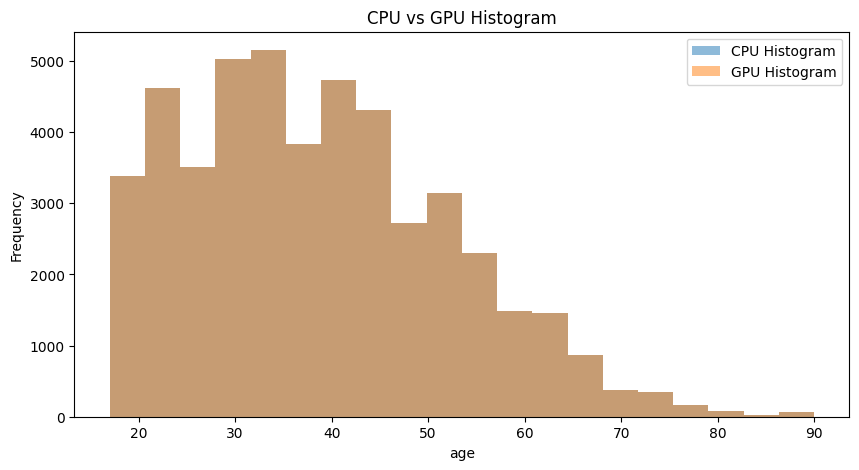


Running GPU Quantile Binning...

Quantile Bin Edges
[17. 26. 33. 41. 50. 90.]

Distribution Across Quantile Bins
[ 9184  8597 10128  9407 10305]


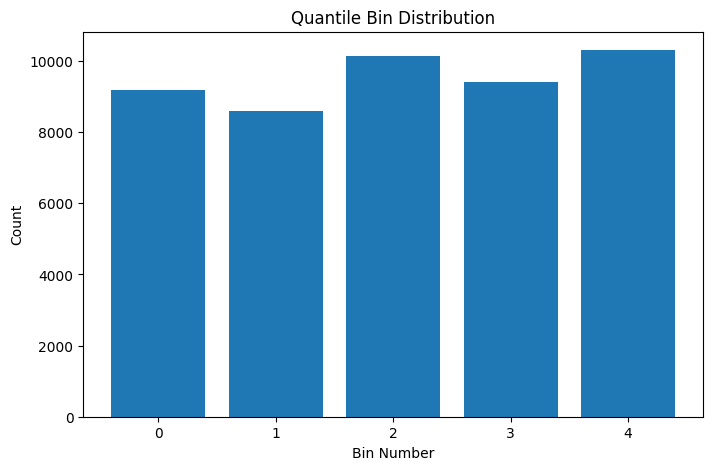


Preparing Data for Training...

Training CPU Random Forest...

CPU Accuracy : 0.8513
CPU Training Time : 3.7008 sec

Training cuML GPU Random Forest...

GPU Accuracy : 0.8580
GPU Training Time : 0.5712 sec

Training XGBoost GPU Model...

XGBoost Accuracy : 0.8662
XGBoost Training Time : 0.3719 sec

Final Comparison Results

                    Model  Accuracy  Training Time (sec)
0       CPU Random Forest  0.851339             3.700835
1  cuML GPU Random Forest  0.857953             0.571241
2             XGBoost GPU  0.866247             0.371861


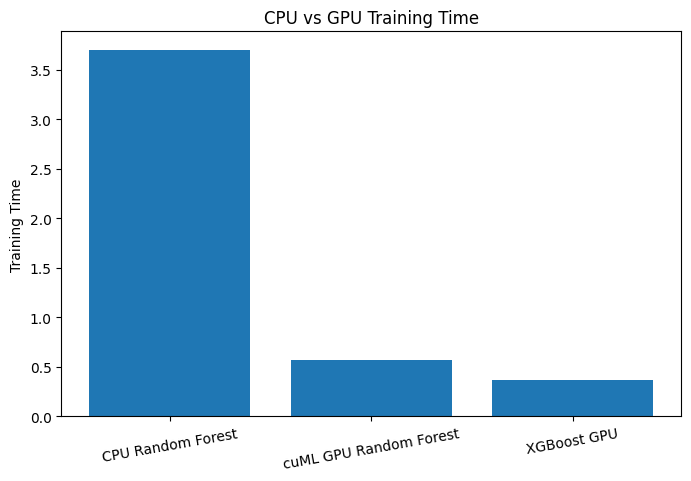

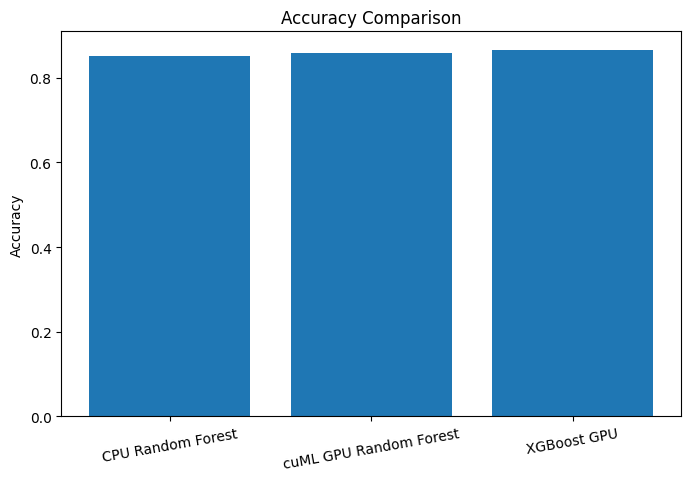

In [4]:
!pip uninstall -y numba -q
!pip install -q numba==0.60.0

!pip install -q cudf-cu12 cuml-cu12 cupy-cuda12x xgboost \
    --extra-index-url=https://pypi.nvidia.com

!pip install -q pandas matplotlib scikit-learn ucimlrepo


import pandas as pd
import numpy as np
import cupy as cp
import cudf
import xgboost as xgb
import matplotlib.pyplot as plt
import time

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split as cu_train_test_split


# ================= LOAD DATASET =================

print("Loading Adult Census Income Dataset...\n")

adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets.iloc[:, 0]

df = pd.concat([X, y], axis=1)

print(df.head())


# ================= FEATURE CLASSIFICATION =================

continuous_features = []
discrete_features = []
categorical_features = []
binary_features = []

for col in df.columns:

    if df[col].dtype == "object":

        if df[col].nunique() == 2:
            binary_features.append(col)

        else:
            categorical_features.append(col)

    else:

        if df[col].nunique() < 20:
            discrete_features.append(col)

        else:
            continuous_features.append(col)


print("\nContinuous Features")
print(continuous_features)

print("\nDiscrete Features")
print(discrete_features)

print("\nCategorical Features")
print(categorical_features)

print("\nBinary Features")
print(binary_features)

print("\nFeatures Suitable for GPU Histogram Binning")
print(continuous_features)


# ================= CLEAN DATA =================

print("\nCleaning Missing Values...\n")

df = df.replace(" ?", np.nan)

df = df.dropna()


# ================= ENCODE FEATURES =================

print("\nEncoding Categorical Features...\n")

target_column = "income"

for col in categorical_features + binary_features:

    # Skip target column
    if col != target_column:

        encoder = LabelEncoder()

        df[col] = encoder.fit_transform(
            df[col].astype(str)
        )


# ================= FIX TARGET LABELS =================

print("\nFixing Target Labels...\n")

df[target_column] = (
    df[target_column]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

df[target_column] = df[target_column].replace({
    "<=50K": 0,
    ">50K": 1
})

df[target_column] = df[target_column].astype(int)

print("\nUnique Target Labels")
print(df[target_column].unique())


# ================= SPLIT FEATURES/TARGET =================

X = df.drop(target_column, axis=1)

y = df[target_column]


# ================= MOVE DATA TO GPU =================

print("\nMoving Data to GPU...\n")

gdf = cudf.from_pandas(X)

selected_feature = continuous_features[0]

print(f"Selected Feature : {selected_feature}")


# ================= GPU HISTOGRAM =================

gpu_array = cp.asarray(
    gdf[selected_feature].values
)

gpu_hist, gpu_bins = cp.histogram(
    gpu_array,
    bins=20
)

cpu_array = X[selected_feature].values

cpu_hist, cpu_bins = np.histogram(
    cpu_array,
    bins=20
)


plt.figure(figsize=(10,5))

plt.hist(
    cpu_array,
    bins=20,
    alpha=0.5,
    label="CPU Histogram"
)

plt.hist(
    cp.asnumpy(gpu_array),
    bins=20,
    alpha=0.5,
    label="GPU Histogram"
)

plt.xlabel(selected_feature)
plt.ylabel("Frequency")
plt.title("CPU vs GPU Histogram")
plt.legend()

plt.show()


# ================= GPU QUANTILE BINNING =================

print("\nRunning GPU Quantile Binning...\n")

quantiles = cp.quantile(
    gpu_array,
    cp.linspace(0, 1, 6)
)

print("Quantile Bin Edges")
print(cp.asnumpy(quantiles))


bin_labels = cp.digitize(
    gpu_array,
    quantiles[1:-1]
)

bin_counts = np.bincount(
    cp.asnumpy(bin_labels)
)

print("\nDistribution Across Quantile Bins")
print(bin_counts)


plt.figure(figsize=(8,5))

plt.bar(
    range(len(bin_counts)),
    bin_counts
)

plt.xlabel("Bin Number")
plt.ylabel("Count")
plt.title("Quantile Bin Distribution")

plt.show()


# ================= TRAIN TEST SPLIT =================

print("\nPreparing Data for Training...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ================= CPU RANDOM FOREST =================

print("Training CPU Random Forest...\n")

start = time.time()

cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cpu_model.fit(X_train, y_train)

cpu_predictions = cpu_model.predict(X_test)

cpu_accuracy = accuracy_score(
    y_test,
    cpu_predictions
)

cpu_time = time.time() - start

print(f"CPU Accuracy : {cpu_accuracy:.4f}")
print(f"CPU Training Time : {cpu_time:.4f} sec")


# ================= cuML GPU RANDOM FOREST =================

print("\nTraining cuML GPU Random Forest...\n")

gX = cudf.from_pandas(X)

gy = cudf.Series(y.values)

gX_train, gX_test, gy_train, gy_test = cu_train_test_split(
    gX,
    gy,
    test_size=0.2,
    random_state=42
)

start = time.time()

gpu_model = cuRF(
    n_estimators=100,
    random_state=42
)

gpu_model.fit(gX_train, gy_train)

gpu_predictions = gpu_model.predict(gX_test)

gpu_accuracy = accuracy_score(
    gy_test.to_pandas(),
    gpu_predictions.to_pandas()
)

gpu_time = time.time() - start

print(f"GPU Accuracy : {gpu_accuracy:.4f}")
print(f"GPU Training Time : {gpu_time:.4f} sec")


# ================= XGBOOST GPU =================

print("\nTraining XGBoost GPU Model...\n")

dtrain = xgb.DMatrix(
    X_train,
    label=y_train.values
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test.values
)

params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "device": "cuda",
    "eval_metric": "logloss"
}

start = time.time()

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=100
)

xgb_predictions = xgb_model.predict(dtest)

xgb_predictions = (
    xgb_predictions > 0.5
).astype(int)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_time = time.time() - start

print(f"XGBoost Accuracy : {xgb_accuracy:.4f}")
print(f"XGBoost Training Time : {xgb_time:.4f} sec")


# ================= FINAL RESULTS =================

results = pd.DataFrame({

    "Model": [
        "CPU Random Forest",
        "cuML GPU Random Forest",
        "XGBoost GPU"
    ],

    "Accuracy": [
        cpu_accuracy,
        gpu_accuracy,
        xgb_accuracy
    ],

    "Training Time (sec)": [
        cpu_time,
        gpu_time,
        xgb_time
    ]
})

print("\nFinal Comparison Results\n")

print(results)


# ================= TRAINING TIME GRAPH =================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Training Time (sec)"]
)

plt.ylabel("Training Time")
plt.title("CPU vs GPU Training Time")

plt.xticks(rotation=10)

plt.show()


# ================= ACCURACY GRAPH =================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.xticks(rotation=10)

plt.show()

Q2. Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML
(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different
levels of GPU parallelism.
1. Data Preparation
o Load the dataset using load_breast_cancer().
o Split it into training and testing sets.
o Convert the dataset into cuDF format for GPU processing.
2. CPU Implementation
o Train a Random Forest model using scikit-learn.
o Record training time, prediction time, and accuracy.
3. GPU Implementation
o Train a Random Forest model using RAPIDS cuML.
o Measure training time, prediction time, and accuracy.
o Compute GPU speedup over the CPU.
4. Visualization of Parallelism
o Forest-Level Parallelism: Plot training time vs. number of trees (n_estimators = 1,
10, 50, 100).
o Feature-Level Parallelism: Plot feature importance from the trained model.
o Data-Level Parallelism: Measure training time for varying dataset sizes.
o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.
5. Performance Comparison
o Create a table comparing CPU and GPU results.
o Visualize execution time using bar charts

Loading Breast Cancer Dataset...

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst textur

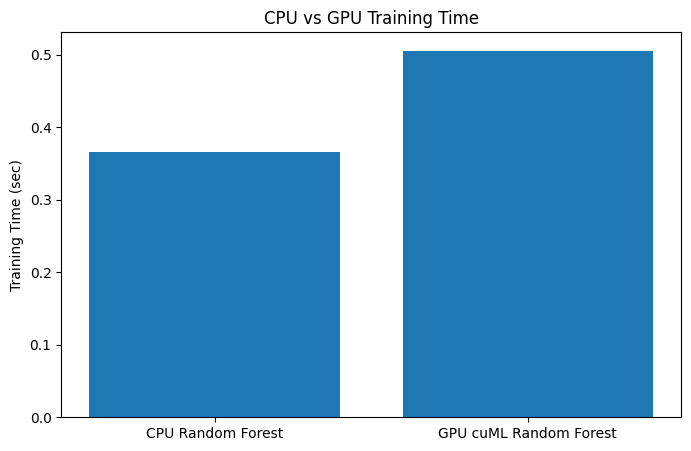

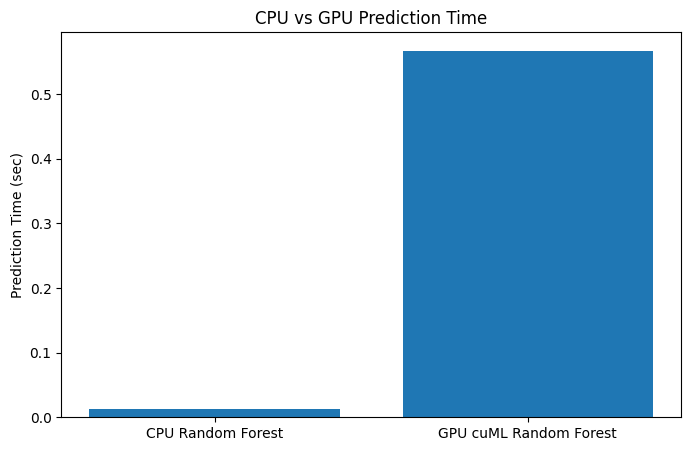


Forest-Level Parallelism

Trees : 1 | Time : 0.0177 sec
Trees : 10 | Time : 0.0534 sec
Trees : 50 | Time : 0.1025 sec
Trees : 100 | Time : 0.2087 sec


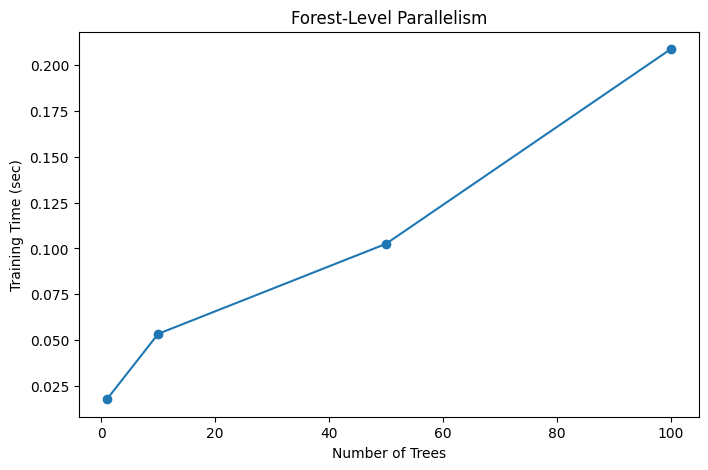


Feature-Level Parallelism



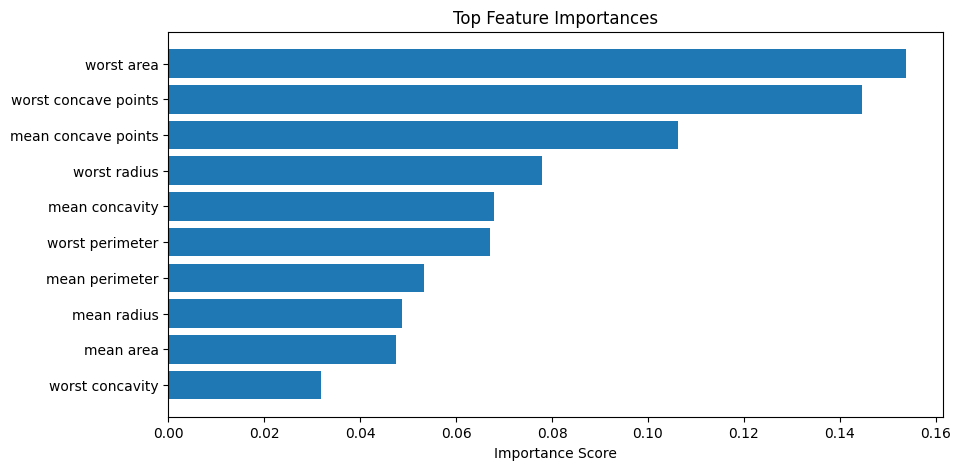


Data-Level Parallelism

Dataset Size : 100 | Time : 0.1144 sec


/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


Dataset Size : 200 | Time : 0.1564 sec
Dataset Size : 400 | Time : 0.1598 sec
Dataset Size : 455 | Time : 0.1558 sec


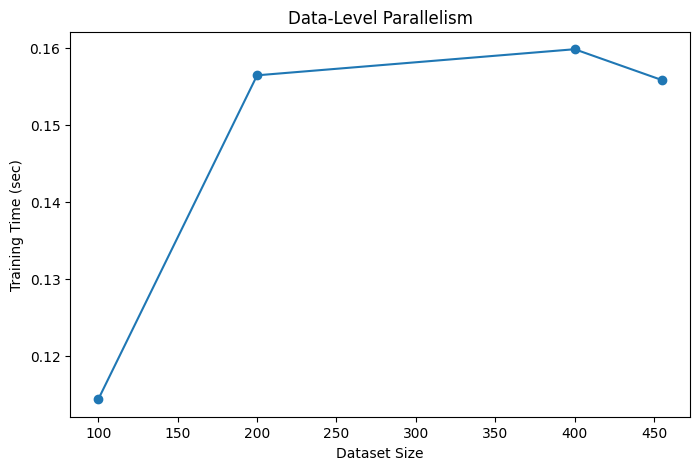


Bin-Level Parallelism using CuPy



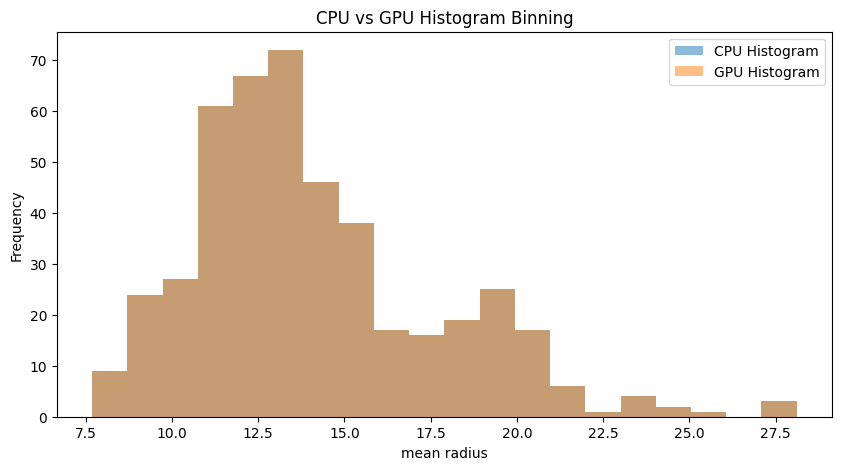

In [2]:
!pip uninstall -y numba -q
!pip install -q numba==0.60.0

!pip install -q cudf-cu12 cuml-cu12 cupy-cuda12x \
    --extra-index-url=https://pypi.nvidia.com

!pip install -q pandas matplotlib scikit-learn

import time
import numpy as np
import pandas as pd
import cupy as cp
import cudf
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from cuml.ensemble import RandomForestClassifier as cuRF


print("Loading Breast Cancer Dataset...\n")

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

print(X.head())


print("\nSplitting Dataset...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Moving Data to GPU...\n")

gX_train = cudf.from_pandas(X_train)
gX_test = cudf.from_pandas(X_test)

gy_train = cudf.Series(y_train.values)
gy_test = cudf.Series(y_test.values)


print("Training CPU Random Forest...\n")

cpu_train_start = time.time()

cpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cpu_model.fit(X_train, y_train)

cpu_train_end = time.time()

cpu_pred_start = time.time()

cpu_predictions = cpu_model.predict(X_test)

cpu_pred_end = time.time()

cpu_accuracy = accuracy_score(
    y_test,
    cpu_predictions
)

cpu_train_time = cpu_train_end - cpu_train_start
cpu_pred_time = cpu_pred_end - cpu_pred_start

print(f"CPU Accuracy : {cpu_accuracy:.4f}")
print(f"CPU Training Time : {cpu_train_time:.4f} sec")
print(f"CPU Prediction Time : {cpu_pred_time:.4f} sec")


print("\nTraining GPU Random Forest...\n")

gpu_train_start = time.time()

gpu_model = cuRF(
    n_estimators=100,
    random_state=42
)

gpu_model.fit(gX_train, gy_train)

gpu_train_end = time.time()

gpu_pred_start = time.time()

gpu_predictions = gpu_model.predict(gX_test)

gpu_pred_end = time.time()

gpu_accuracy = accuracy_score(
    gy_test.to_pandas(),
    gpu_predictions.to_pandas()
)

gpu_train_time = gpu_train_end - gpu_train_start
gpu_pred_time = gpu_pred_end - gpu_pred_start

print(f"GPU Accuracy : {gpu_accuracy:.4f}")
print(f"GPU Training Time : {gpu_train_time:.4f} sec")
print(f"GPU Prediction Time : {gpu_pred_time:.4f} sec")


speedup = cpu_train_time / gpu_train_time

print(f"\nGPU Speedup : {speedup:.2f}x")


results = pd.DataFrame({

    "Model": [
        "CPU Random Forest",
        "GPU cuML Random Forest"
    ],

    "Accuracy": [
        cpu_accuracy,
        gpu_accuracy
    ],

    "Training Time": [
        cpu_train_time,
        gpu_train_time
    ],

    "Prediction Time": [
        cpu_pred_time,
        gpu_pred_time
    ]
})

print("\nPerformance Comparison\n")

print(results)


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Training Time"]
)

plt.ylabel("Training Time (sec)")
plt.title("CPU vs GPU Training Time")

plt.show()


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Prediction Time"]
)

plt.ylabel("Prediction Time (sec)")
plt.title("CPU vs GPU Prediction Time")

plt.show()


print("\nForest-Level Parallelism\n")

tree_values = [1, 10, 50, 100]

forest_times = []

for trees in tree_values:

    start = time.time()

    model = cuRF(
        n_estimators=trees,
        random_state=42
    )

    model.fit(gX_train, gy_train)

    end = time.time()

    forest_times.append(end - start)

    print(f"Trees : {trees} | Time : {end-start:.4f} sec")


plt.figure(figsize=(8,5))

plt.plot(
    tree_values,
    forest_times,
    marker='o'
)

plt.xlabel("Number of Trees")
plt.ylabel("Training Time (sec)")
plt.title("Forest-Level Parallelism")

plt.show()


print("\nFeature-Level Parallelism\n")

feature_importance = cpu_model.feature_importances_

feature_names = X.columns

sorted_idx = np.argsort(feature_importance)[::-1][:10]

top_features = feature_names[sorted_idx]

top_importance = feature_importance[sorted_idx]


plt.figure(figsize=(10,5))

plt.barh(
    top_features,
    top_importance
)

plt.xlabel("Importance Score")
plt.title("Top Feature Importances")

plt.gca().invert_yaxis()

plt.show()


print("\nData-Level Parallelism\n")

dataset_sizes = [100, 200, 400, len(X_train)]

data_times = []

for size in dataset_sizes:

    subset_X = gX_train.iloc[:size]
    subset_y = gy_train.iloc[:size]

    start = time.time()

    model = cuRF(
        n_estimators=100,
        random_state=42
    )

    model.fit(subset_X, subset_y)

    end = time.time()

    data_times.append(end - start)

    print(f"Dataset Size : {size} | Time : {end-start:.4f} sec")


plt.figure(figsize=(8,5))

plt.plot(
    dataset_sizes,
    data_times,
    marker='o'
)

plt.xlabel("Dataset Size")
plt.ylabel("Training Time (sec)")
plt.title("Data-Level Parallelism")

plt.show()


print("\nBin-Level Parallelism using CuPy\n")

selected_feature = X.columns[0]

gpu_feature = cp.asarray(
    gX_train[selected_feature].values
)

gpu_hist, gpu_bins = cp.histogram(
    gpu_feature,
    bins=20
)

cpu_feature = X_train[selected_feature].values

plt.figure(figsize=(10,5))

plt.hist(
    cpu_feature,
    bins=20,
    alpha=0.5,
    label="CPU Histogram"
)

plt.hist(
    cp.asnumpy(gpu_feature),
    bins=20,
    alpha=0.5,
    label="GPU Histogram"
)

plt.xlabel(selected_feature)
plt.ylabel("Frequency")
plt.title("CPU vs GPU Histogram Binning")
plt.legend()

plt.show()